# Determination of rejection threshold
In this experiment, we try to determine a threshold for the cosine distance between a query embedding and the gallery embeddings to decide whether an individual is *known* (= was part of the training set) or *unknown* (= new individual). We call this the *rejection threshold* because if a query embedding exceeds this threshold it is rejected as *uknown*. To determine the rejection threshold, we train the model on all data from recording session *A1* and tune our threshold on the independent recording session *A2*. Both sessions were part of recording period *A*.

In [1]:
# point this path to the folder containing all experiment data sets
DATA_DIR = r"D:\wingprint_paper\free_flight"

## Training
The training set only includes individuals with at least 15 approaches and the approaches per individual in the training set are limited to 50.

In [ ]:
import glob
from matplotlib import pyplot as plt
import numpy as np
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from optuna.samplers import TPESampler
import os
import seaborn as sns
from sklearn.metrics import pairwise_distances, confusion_matrix
import sys
import torch

sys.path.append("..")

from batset import Batset
import arcface_model
import utils

sns.set_theme()

TRAIN_DIR = os.path.join(DATA_DIR, "finalized_datasets", "A1_balanced")
TEST_DIR = os.path.join(DATA_DIR, "finalized_datasets", "A2_complete")
STATS_DIR = os.path.join("stats", "find_threshold")                     # for plots and models
CHECKPOINTS_DIR = os.path.join("checkpoints", "find_threshold")         # for model checkpoints

os.makedirs(STATS_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

# ensure consistent behaviour between runs by seeding random modules and disabling non-deterministic algorithms in PyTorch and CUDA
utils.seed_everything()

num_classes = len(glob.glob(os.path.join(TRAIN_DIR, '*')))

mean, std = utils.calc_mean_std_from_paths([TRAIN_DIR], limit=None)
gallery_transform = arcface_model.compose_input_transform(mean, std, image_target_size=arcface_model.IMG_SIZE)

train_data = Batset(TRAIN_DIR, transform=gallery_transform)
trainloader = torch.utils.data.DataLoader(train_data, batch_size=arcface_model.BATCH_SIZE, shuffle=True)

device = utils.get_device()

model = arcface_model.train_model(device, num_classes, trainloader)
torch.save(model.state_dict(), os.path.join(CHECKPOINTS_DIR, "model.pth"))

calculate mean and std of ['D:\\wingprint_paper\\free_flight\\finalized_datasets\\A1_balanced']


100%|██████████| 10794/10794 [01:58<00:00, 90.79it/s]


Calculated mean: tensor([0.2952, 0.2952, 0.2952]), std: tensor([0.1608, 0.1608, 0.1608])
load dataset from D:\wingprint_paper\free_flight\finalized_datasets\A1_balanced
loaded 10794 images within 15 classes
found CUDA device NVIDIA GeForce RTX 4060 Ti
initialize model
start training for maximum 50 epochs
4 mins -> Epoch 1/50.. Train loss: 23.6392, Learning rate: [1e-05]
8 mins -> Epoch 2/50.. Train loss: 3.6860, Learning rate: [8.5e-06]
12 mins -> Epoch 3/50.. Train loss: 0.7840, Learning rate: [7.2249999999999994e-06]
17 mins -> Epoch 4/50.. Train loss: 0.3210, Learning rate: [6.141249999999999e-06]
21 mins -> Epoch 5/50.. Train loss: 0.1891, Learning rate: [5.220062499999999e-06]
25 mins -> Epoch 6/50.. Train loss: 0.1263, Learning rate: [4.4370531249999995e-06]
30 mins -> Epoch 7/50.. Train loss: 0.1035, Learning rate: [3.7714951562499997e-06]
34 mins -> Epoch 8/50.. Train loss: 0.0727, Learning rate: [3.2057708828124997e-06]
early stopping due to loss < 0.15


## Build gallery and queries

After training, we fill the gallery with the training data and generate queries from the test data. Since we know which of the approaches of the training set belong together, we insert only the class centroids in the gallery. This helps eliminate outliers and reduces computational effort due to less comparisons when evaluating the queries.

In [3]:
mean, std = utils.calc_mean_std_from_paths([TEST_DIR], limit=None)
query_transform = arcface_model.compose_input_transform(mean, std, image_target_size=arcface_model.IMG_SIZE)

gallery_embeddings, gallery_names, query_embeddings, query_names = utils.build_gallery_queries(device, model, TRAIN_DIR, TEST_DIR, gallery_transform, query_transform)

calculate mean and std of ['D:\\wingprint_paper\\free_flight\\finalized_datasets\\A2_complete']


100%|██████████| 24219/24219 [04:47<00:00, 84.24it/s] 


Calculated mean: tensor([0.4009, 0.4009, 0.4009]), std: tensor([0.2068, 0.2068, 0.2068])
build gallery


100%|██████████| 15/15 [07:01<00:00, 28.12s/it]


generate queries


100%|██████████| 30/30 [17:43<00:00, 35.46s/it]


## Determine a rejection threshold
To optimize the rejection threshold, we use an Optuna study that sweeps across potential thresholds and minimizes the difference between:
- the *false positive rate*, therefore the relative amount of *unknown* individuals that have falsely been classified as *known*
- the *false negative rate*, therefore the relative amount of *known* individuals that have been falsely rejected

By minimizing this difference, we get a threshold that balances both types of errors, defining the *equal error rate*.

  0%|          | 0/100 [00:00<?, ?it/s]

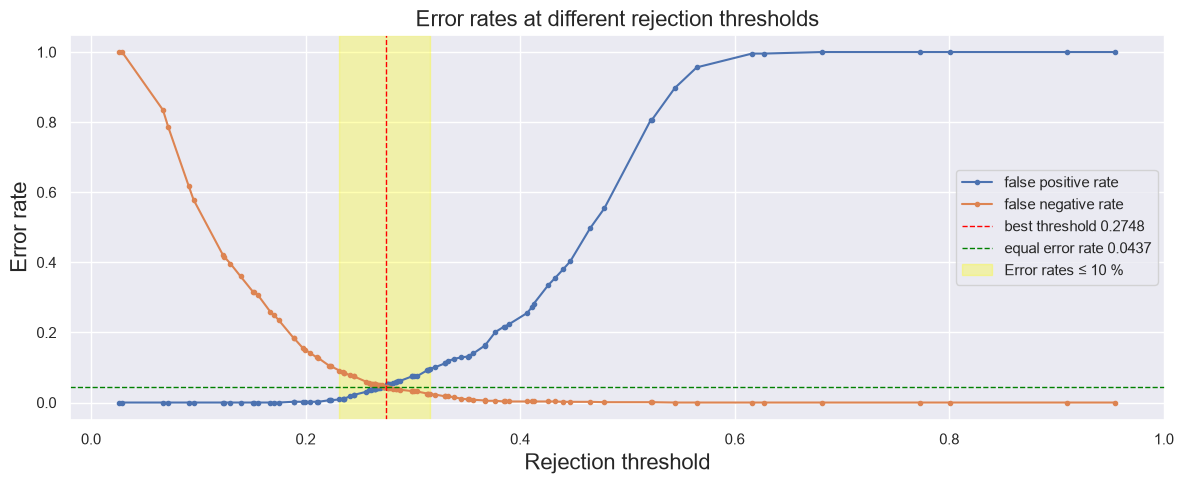

In [4]:
# classes are known if they have a match in the training set
matchable_classes = [int(os.path.basename(path)) for path in glob.glob(os.path.join(TRAIN_DIR, '*'))]

# create an unknown class with index num_classes
UNKNOWN_CLASS = num_classes

fprs = []
fnrs = []

def objective(trial):
    threshold = trial.suggest_float('threshold', 0.01, 0.99)

    predictions = []
    targets = []

    for point, individual_ID in zip(query_embeddings, query_names):
        if individual_ID in matchable_classes:
            targets.append(train_data.class_map[individual_ID])
        else:
            targets.append(UNKNOWN_CLASS)

        dists = pairwise_distances(point.reshape(1, -1), gallery_embeddings, metric='cosine').squeeze()
        min_dist = dists.min()

        if min_dist <= threshold:
            idx = dists.argmin()
            predicted_name = gallery_names[idx]

            predictions.append(train_data.class_map[predicted_name])
        else:
            predictions.append(UNKNOWN_CLASS)

    # rejection is a binary problem, so all unknowns = 0 and all knowns = 1
    rejection_predictions = [0 if p == UNKNOWN_CLASS else 1 for p in predictions]
    rejection_targets = [0 if t == UNKNOWN_CLASS else 1 for t in targets]
    
    tn, fp, fn, tp = confusion_matrix(rejection_targets, rejection_predictions).ravel()
    
    fpr = fp/(fp+tn)
    fnr = fn/(fn+tp)

    fprs.append((threshold, fpr))
    fnrs.append((threshold, fnr))

    return abs(fpr-fnr)

# this study minimizes the difference between false positive rate and false negative rate in order to find the equal error rate
study = optuna.create_study(study_name="BatStudy", direction='minimize', sampler=TPESampler(seed=utils.SEED))
study.optimize(objective, n_trials=100, show_progress_bar=True)

thresholds = []
differences = []

for trial in study.trials:
    thresholds.append(trial.params['threshold'])
    differences.append(trial.value)

fpr_values = [x for _, x in sorted(fprs)]
fnr_values = [x for _, x in sorted(fnrs)]
difference_values = [x for _, x in sorted(zip(thresholds, differences))]
thresholds.sort()

equal_error_rate = (fpr_values[np.argmin(difference_values)]+fnr_values[np.argmin(difference_values)])/2
ten_percent_range = [thresholds[i] for i, (fpr, fnr) in enumerate(zip(fpr_values, fnr_values)) if fpr <= 0.1 and fnr <= 0.1]
  
plt.figure(figsize=(12, 5))

plt.plot(thresholds, fpr_values, marker='.', label="false positive rate")
plt.plot(thresholds, fnr_values, marker='.', label="false negative rate")
plt.axvline(study.best_params['threshold'], color='red', linestyle='--', linewidth=1, label=f"best threshold {study.best_params['threshold']:.4f}")
plt.axhline(equal_error_rate, color='green', linestyle='--', linewidth=1, label=f"equal error rate {equal_error_rate:.4f}")
plt.axvspan(ten_percent_range[0], ten_percent_range[-1], color='yellow', alpha=0.3, label="Error rates ≤ 10 %")

plt.xlabel(f"Rejection threshold", fontdict = {'fontsize' : 16})
plt.ylabel("Error rate", fontdict = {'fontsize' : 16})
plt.title(f"Error rates at different rejection thresholds", fontdict = {'fontsize' : 16})
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(STATS_DIR, "Open_Set_Threshold_Tuning.pdf"))